# Telco Customer Churn — End-to-End Prediction with PySpark & Databricks

**Business question:** How can a telecom operator identify customers at high risk of churn early enough to prioritize retention actions?

Workflow: **Business understanding → Data quality → EDA → Cleaning → Feature engineering → Serverless-safe encoding → Spark ML → Evaluation → Threshold analysis → Customer scoring → Business actions**

Dataset: **7,043 customers · 21 raw columns · 1,869 churners · churn rate 26.54%**

> This notebook is designed for Databricks Free Edition / serverless Environment v4+. It intentionally avoids `cache()`, `persist()`, and preprocessing pipelines that create many fitted Spark ML model objects in memory.

## 1. Environment & imports
PySpark is provided by Databricks. Pandas and Matplotlib are used for compact result tables and plots.

In [0]:
import gc
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

print(f"Spark version: {spark.version}")

Spark version: 4.1.0


## 2. Load the raw dataset
Upload the CSV to a Databricks Volume and set the widget to its exact path.

In [0]:
dbutils.widgets.text(
    "dataset_path",
    "/Volumes/workspace/default/chrum_table/WA_Fn-UseC_Telco-Customer-Churn.csv",
    "Dataset path",
)
FILE_PATH = dbutils.widgets.get("dataset_path")

if "<catalog>" in FILE_PATH:
    raise ValueError("Set the 'Dataset path' widget to the real CSV location.")

df_raw = spark.read.csv(FILE_PATH, header=True, inferSchema=True)

print(f"Rows: {df_raw.count():,}")
print(f"Columns: {len(df_raw.columns)}")
display(df_raw.limit(5))
df_raw.printSchema()

Rows: 7,043
Columns: 21


customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes


root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)



## 3. Data quality audit
The supplied dataset contains **11 blank `TotalCharges` values**. They correspond to customers with `tenure = 0`. We retain these customers and map blank historical charges to `0.0`.

In [0]:
string_cols = [c for c, t in df_raw.dtypes if t == "string"]
numeric_cols_raw = [c for c, t in df_raw.dtypes if t != "string"]

missing_exprs = []
for c in string_cols:
    missing_exprs.append(
        F.sum(
            F.when(F.col(c).isNull() | (F.trim(F.col(c)) == ""), 1).otherwise(0)
        ).alias(c)
    )

for c in numeric_cols_raw:
    missing_exprs.append(
        F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    )

display(df_raw.select(missing_exprs))

blank_totalcharges = df_raw.filter(F.trim(F.col("TotalCharges")) == "")
print(f"Blank TotalCharges rows: {blank_totalcharges.count()}")
display(blank_totalcharges.select("customerID", "tenure", "MonthlyCharges", "TotalCharges"))

customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn,SeniorCitizen,tenure,MonthlyCharges
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0


Blank TotalCharges rows: 11


customerID,tenure,MonthlyCharges,TotalCharges
4472-LVYGI,0,52.55,
3115-CZMZD,0,20.25,
5709-LVOEQ,0,80.85,
4367-NUYAO,0,25.75,
1371-DWPAZ,0,56.05,
7644-OMVMY,0,19.85,
3213-VVOLG,0,25.35,
2520-SGTTA,0,20.0,
2923-ARZLG,0,19.7,
4075-WKNIU,0,73.35,


## 4. Exploratory Data Analysis
Key descriptive results from the supplied CSV:
- Overall churn: **26.54%**
- Month-to-month: **42.71%**
- Fiber optic: **41.89%**
- Electronic check: **45.29%**
- No TechSupport: **41.64%**
- No OnlineSecurity: **41.77%**
- Senior customers: **41.68%**
- Median tenure: **10 months for churners vs 38 months for retained customers**

These are associations, not causal effects.

Each Databricks table below is followed by a native Matplotlib visualization generated from the same aggregated values.

Churn,count,share
No,5174,0.7346301292063041
Yes,1869,0.2653698707936959


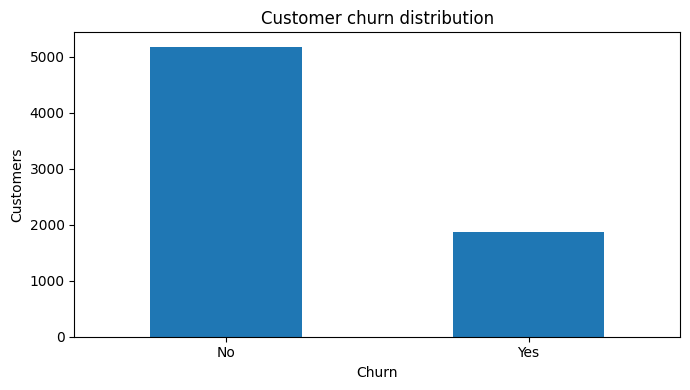


### Contract


Contract,customers,churners,churn_rate
Month-to-month,3875,1655,0.4270967741935484
One year,1473,166,0.11269517990495587
Two year,1695,48,0.02831858407079646


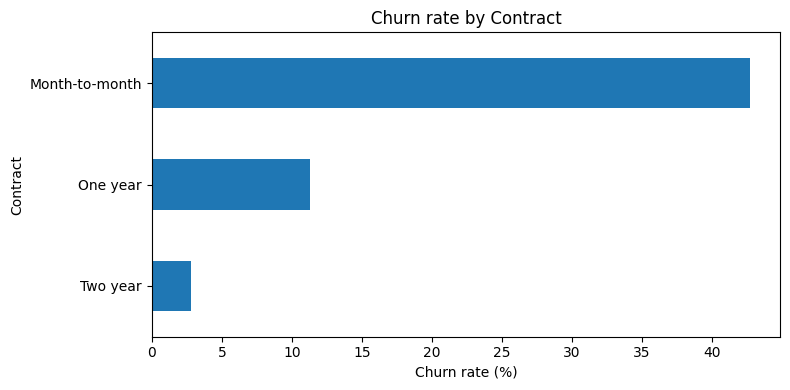


### InternetService


InternetService,customers,churners,churn_rate
Fiber optic,3096,1297,0.4189276485788114
DSL,2421,459,0.1895910780669145
No,1526,113,0.07404980340760157


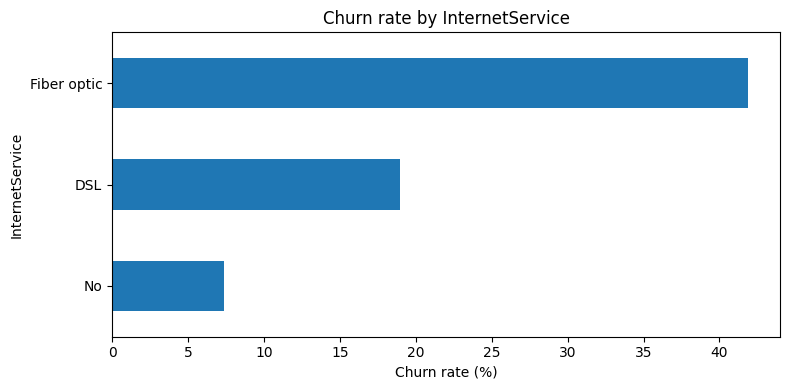


### PaymentMethod


PaymentMethod,customers,churners,churn_rate
Electronic check,2365,1071,0.4528541226215645
Mailed check,1612,308,0.19106699751861042
Bank transfer (automatic),1544,258,0.16709844559585493
Credit card (automatic),1522,232,0.15243101182654403


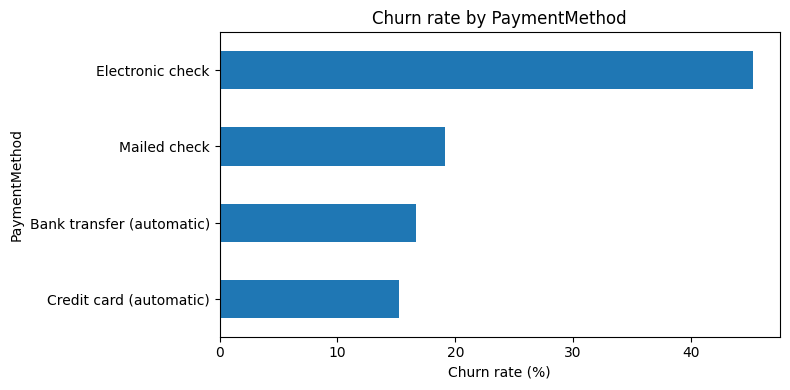


### TechSupport


TechSupport,customers,churners,churn_rate
No,3473,1446,0.4163547365390153
Yes,2044,310,0.15166340508806261
No internet service,1526,113,0.07404980340760157


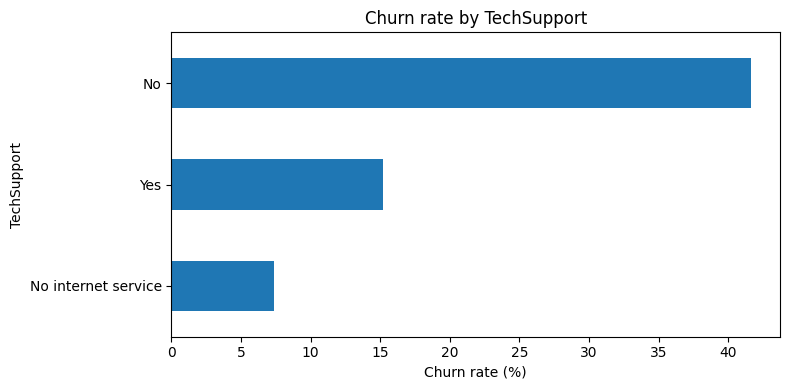


### OnlineSecurity


OnlineSecurity,customers,churners,churn_rate
No,3498,1461,0.4176672384219554
Yes,2019,295,0.14611193660227836
No internet service,1526,113,0.07404980340760157


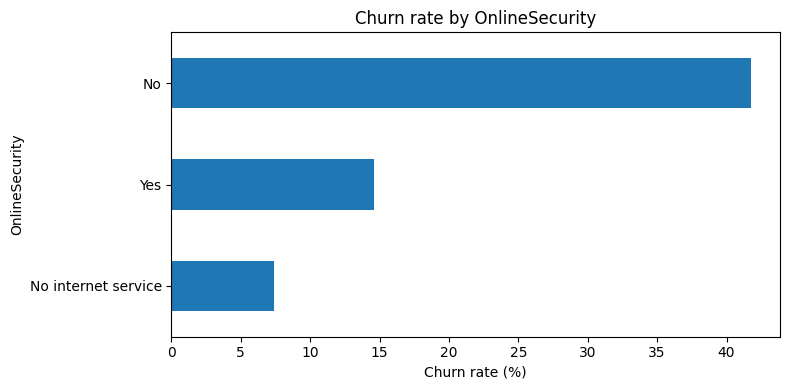


### SeniorCitizen


SeniorCitizen,customers,churners,churn_rate
1,1142,476,0.4168126094570928
0,5901,1393,0.23606168446026096


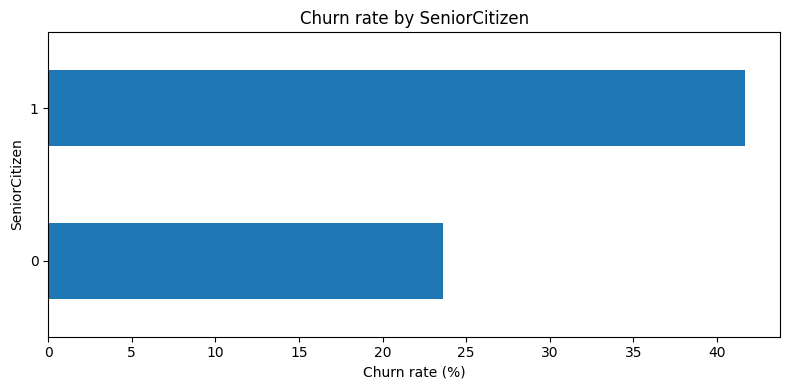


### PaperlessBilling


PaperlessBilling,customers,churners,churn_rate
Yes,4171,1400,0.33565092304003835
No,2872,469,0.1633008356545961


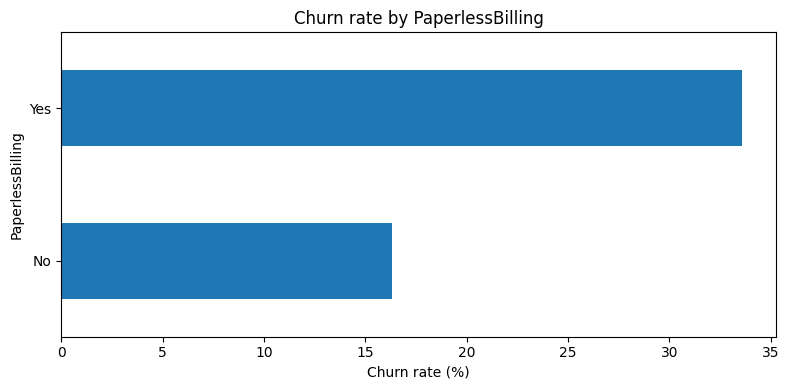


### Partner


Partner,customers,churners,churn_rate
No,3641,1200,0.32957978577313923
Yes,3402,669,0.1966490299823633


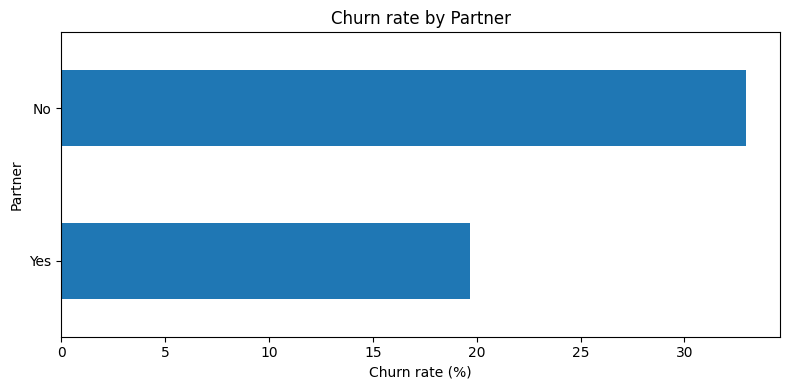


### Dependents


Dependents,customers,churners,churn_rate
No,4933,1543,0.3127914048246503
Yes,2110,326,0.15450236966824646


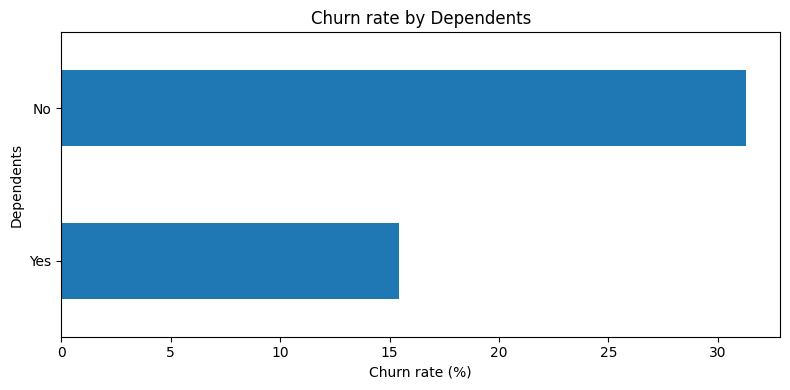


### gender


gender,customers,churners,churn_rate
Female,3488,939,0.26920871559633025
Male,3555,930,0.2616033755274262


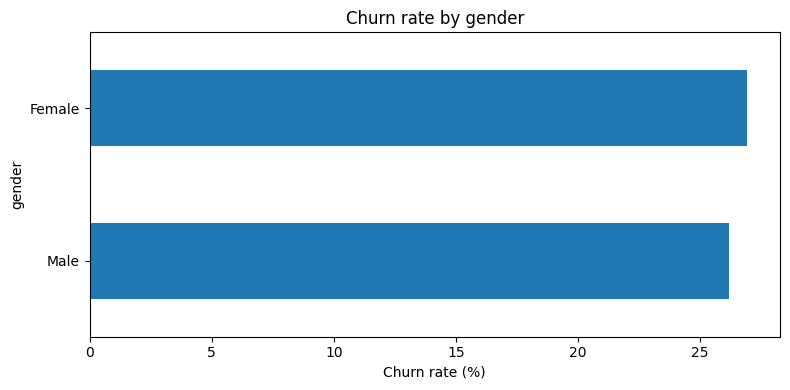

In [0]:
def churn_rate_table(df, column):
    return (
        df.groupBy(column)
        .agg(
            F.count("*").alias("customers"),
            F.sum(F.when(F.col("Churn") == "Yes", 1).otherwise(0)).alias("churners"),
        )
        .withColumn("churn_rate", F.col("churners") / F.col("customers"))
        .orderBy(F.desc("churn_rate"))
    )

n_customers = df_raw.count()

# Target distribution: Databricks table first, Matplotlib chart second.
target_dist = (
    df_raw.groupBy("Churn")
    .count()
    .withColumn("share", F.col("count") / F.lit(n_customers))
    .orderBy(F.desc("count"))
)
display(target_dist)

target_pd = target_dist.toPandas()
ax = target_pd.plot.bar(
    x="Churn",
    y="count",
    figsize=(7, 4),
    legend=False,
)
ax.set_title("Customer churn distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Categorical EDA: keep every Databricks table, then render its real Matplotlib chart.
for col_name in [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "SeniorCitizen",
    "PaperlessBilling",
    "Partner",
    "Dependents",
    "gender",
]:
    print(f"\n### {col_name}")
    segment_table = churn_rate_table(df_raw, col_name)
    display(segment_table)

    segment_pd = segment_table.toPandas()
    segment_pd[col_name] = segment_pd[col_name].astype(str)
    segment_pd["churn_rate_pct"] = segment_pd["churn_rate"] * 100

    ax = (
        segment_pd
        .sort_values("churn_rate_pct")
        .plot.barh(
            x=col_name,
            y="churn_rate_pct",
            figsize=(8, 4),
            legend=False,
        )
    )
    ax.set_title(f"Churn rate by {col_name}")
    ax.set_xlabel("Churn rate (%)")
    ax.set_ylabel(col_name)
    plt.tight_layout()
    plt.show()


Churn,avg_tenure,median_tenure,avg_monthly_charges,avg_total_charges
Yes,17.98,10,74.44,1531.8
No,37.57,38,61.27,2549.91


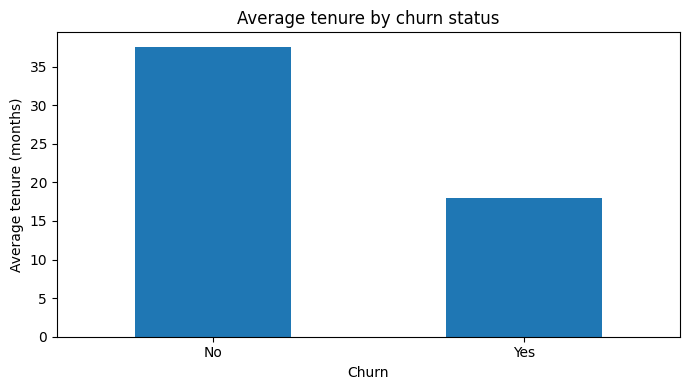

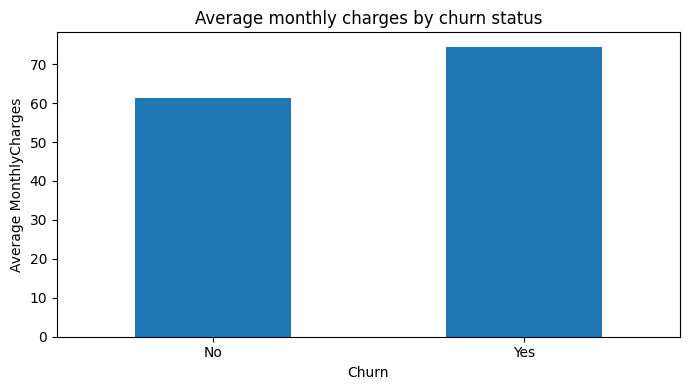

In [0]:
eda_numeric = df_raw.withColumn(
    "TotalCharges_numeric",
    F.when(
        F.col("TotalCharges").isNull() | (F.trim(F.col("TotalCharges")) == ""),
        F.lit(0.0),
    ).otherwise(F.col("TotalCharges").cast("double"))
)

numeric_summary = eda_numeric.groupBy("Churn").agg(
    F.round(F.avg("tenure"), 2).alias("avg_tenure"),
    F.expr("percentile_approx(tenure, 0.5)").alias("median_tenure"),
    F.round(F.avg("MonthlyCharges"), 2).alias("avg_monthly_charges"),
    F.round(F.avg("TotalCharges_numeric"), 2).alias("avg_total_charges"),
)

display(numeric_summary)

numeric_pd = numeric_summary.toPandas().sort_values("Churn")

ax = numeric_pd.plot.bar(
    x="Churn",
    y="avg_tenure",
    figsize=(7, 4),
    legend=False,
)
ax.set_title("Average tenure by churn status")
ax.set_xlabel("Churn")
ax.set_ylabel("Average tenure (months)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ax = numeric_pd.plot.bar(
    x="Churn",
    y="avg_monthly_charges",
    figsize=(7, 4),
    legend=False,
)
ax.set_title("Average monthly charges by churn status")
ax.set_xlabel("Churn")
ax.set_ylabel("Average MonthlyCharges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Cleaning & feature engineering
`customerID` is retained for scoring but excluded from predictive features.

Engineered variables:
- `num_services`: number of active services among eight telecom options.
- `charges_per_month`: historical total charges divided by tenure; `MonthlyCharges` is used for tenure = 0.

In [0]:
df = (
    df_raw
    .withColumn(
        "TotalCharges",
        F.when(
            F.col("TotalCharges").isNull() | (F.trim(F.col("TotalCharges")) == ""),
            F.lit(0.0),
        ).otherwise(F.col("TotalCharges")).cast("double"),
    )
    .withColumn(
        "label",
        F.when(F.col("Churn") == "Yes", F.lit(1.0)).otherwise(F.lit(0.0)),
    )
)

service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

service_flags = [F.when(F.col(c) == "Yes", 1).otherwise(0) for c in service_cols]

df = (
    df
    .withColumn("num_services", sum(service_flags))
    .withColumn(
        "charges_per_month",
        F.when(
            F.col("tenure") > 0,
            F.col("TotalCharges") / F.col("tenure"),
        ).otherwise(F.col("MonthlyCharges")),
    )
)

## 6. Train / test split
The split is performed before categorical vocabulary is learned.

In [0]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print(f"Train rows: {train_df.count():,}")
print(f"Test rows : {test_df.count():,}")
display(train_df.groupBy("label").count().orderBy("label"))
display(test_df.groupBy("label").count().orderBy("label"))

Train rows: 5,634
Test rows : 1,409


label,count
0.0,4148
1.0,1486


label,count
0.0,1026
1.0,383


## 7. Serverless-safe categorical encoding
Databricks Free Edition limits the total size of Spark ML models cached in one serverless session. To avoid creating many `StringIndexerModel` and `OneHotEncoderModel` objects, categorical variables are encoded deterministically with Spark column expressions.

The category vocabulary is learned **from the training set only**. One level per categorical feature is used as the baseline, so the resulting representation is standard dummy encoding without a fitted preprocessing model.

In [0]:
categorical_cols = [
    c for c, t in df.dtypes
    if t == "string" and c not in ["customerID", "Churn"]
]

numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "num_services",
    "charges_per_month",
]

category_levels = {}
for c in categorical_cols:
    levels = [r[0] for r in train_df.select(c).distinct().collect() if r[0] is not None]
    category_levels[c] = sorted(levels)


def safe_token(value):
    token = re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_")
    return token if token else "value"


def encode_categoricals(input_df, levels_dict):
    out = input_df
    encoded = []
    for col_name, levels in levels_dict.items():
        # first sorted level is the baseline and is intentionally omitted
        for level in levels[1:]:
            new_col = f"{col_name}__{safe_token(level)}"
            out = out.withColumn(
                new_col,
                F.when(F.col(col_name) == F.lit(level), F.lit(1.0)).otherwise(F.lit(0.0)),
            )
            encoded.append(new_col)
    return out, encoded

train_encoded, encoded_cols = encode_categoricals(train_df, category_levels)
test_encoded, _ = encode_categoricals(test_df, category_levels)
full_encoded, _ = encode_categoricals(df, category_levels)

feature_cols = encoded_cols + numeric_cols
print(f"Predictive feature dimensions: {len(feature_cols)}")
print("First features:", feature_cols[:12])

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="keep",
)

train_vec = assembler.transform(train_encoded)
test_vec = assembler.transform(test_encoded)
full_vec = assembler.transform(full_encoded)

Predictive feature dimensions: 32
First features: ['gender__Male', 'Partner__Yes', 'Dependents__Yes', 'PhoneService__Yes', 'MultipleLines__No_phone_service', 'MultipleLines__Yes', 'InternetService__Fiber_optic', 'InternetService__No', 'OnlineSecurity__No_internet_service', 'OnlineSecurity__Yes', 'OnlineBackup__No_internet_service', 'OnlineBackup__Yes']


## 8. Evaluation framework
We calculate ROC-AUC, PR-AUC, Accuracy, Weighted F1, churn Precision / Recall / F1, and TN / FP / FN / TP.

For retention, false negatives are especially important because they are actual churners that are not flagged.

In [0]:
def evaluate_predictions(predictions, model_name):
    auc_roc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC",
    ).evaluate(predictions)

    pr_auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderPR",
    ).evaluate(predictions)

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy",
    ).evaluate(predictions)

    weighted_f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1",
    ).evaluate(predictions)

    counts = {
        (float(r["label"]), float(r["prediction"])): int(r["count"])
        for r in predictions.groupBy("label", "prediction").count().collect()
    }

    tn = counts.get((0.0, 0.0), 0)
    fp = counts.get((0.0, 1.0), 0)
    fn = counts.get((1.0, 0.0), 0)
    tp = counts.get((1.0, 1.0), 0)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "Model": model_name,
        "AUC_ROC": auc_roc,
        "PR_AUC": pr_auc,
        "Accuracy": accuracy,
        "Weighted_F1": weighted_f1,
        "Churn_Precision": precision,
        "Churn_Recall": recall,
        "Churn_F1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

## 9. Model 1 — Logistic Regression
Spark Logistic Regression standardizes features internally during optimization by default, so an additional fitted `StandardScalerModel` is unnecessary here. This also keeps the serverless model cache small.

In [0]:
# Remove stale model references if this cell is re-run in the same session.
for model_name in ["lr_model", "rf_model"]:
    if model_name in globals():
        del globals()[model_name]
gc.collect()

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=30,
    regParam=0.05,
    family="binomial",
    standardization=True,
)

lr_model = lr.fit(train_vec)
pred_lr = lr_model.transform(test_vec)
lr_metrics = evaluate_predictions(pred_lr, "Logistic Regression")
display(pd.DataFrame([lr_metrics]).round(4))

# Materialize only the small scoring outputs locally so the LR model can be released
# before Random Forest is trained.
lr_test_pd = (
    pred_lr
    .select(
        "customerID",
        "label",
        "prediction",
        vector_to_array("probability")[1].alias("churn_probability"),
    )
    .toPandas()
)

scored_all_pd = (
    lr_model.transform(full_vec)
    .select(
        "customerID",
        vector_to_array("probability")[1].alias("churn_probability"),
    )
    .toPandas()
)

Model,AUC_ROC,PR_AUC,Accuracy,Weighted_F1,Churn_Precision,Churn_Recall,Churn_F1,TN,FP,FN,TP
Logistic Regression,0.8369,0.6347,0.7921,0.78,0.6642,0.4752,0.554,934,92,201,182


## 10. Threshold analysis — Logistic Regression
The default 0.50 threshold is not necessarily optimal for retention. Because the test set is small, threshold analysis is performed locally on the already-materialized probabilities, avoiding additional Spark ML model objects.

threshold,churn_precision,churn_recall,churn_f1,TN,FP,FN,TP
0.2,0.4798,0.8381,0.6103,678,348,62,321
0.25,0.5209,0.812,0.6347,740,286,72,311
0.3,0.5583,0.7624,0.6446,795,231,91,292
0.35,0.5904,0.6736,0.6293,847,179,125,258
0.4,0.6114,0.6162,0.6138,876,150,147,236
0.45,0.6495,0.5614,0.6022,910,116,168,215
0.5,0.6642,0.4752,0.554,934,92,201,182
0.55,0.7023,0.3943,0.505,962,64,232,151
0.6,0.7383,0.2872,0.4135,987,39,273,110
0.65,0.7273,0.188,0.2988,999,27,311,72


Exploratory threshold maximizing churn F1 on this test set: 0.30
For production, choose a threshold on validation data using business costs, not the test set.


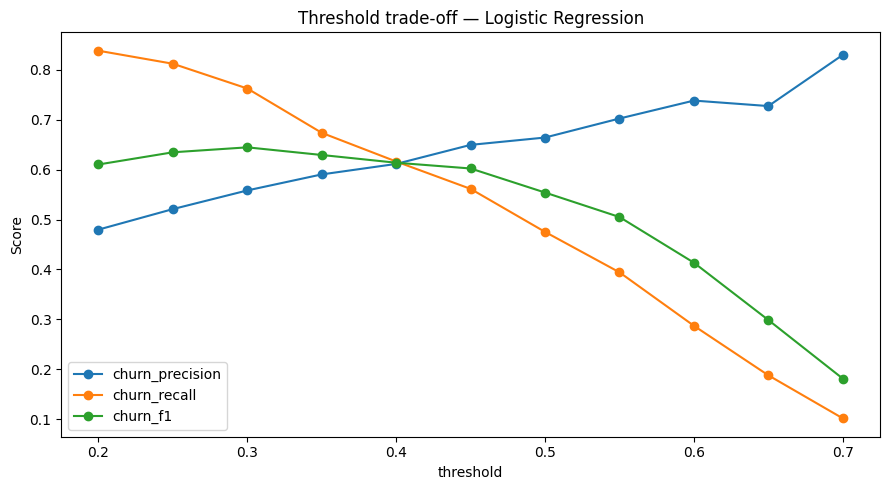

In [0]:
threshold_rows = []
y_true = lr_test_pd["label"].astype(int).to_numpy()
proba = lr_test_pd["churn_probability"].to_numpy()

for threshold in np.arange(0.20, 0.71, 0.05):
    threshold = float(round(threshold, 2))
    y_pred = (proba >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    threshold_rows.append({
        "threshold": threshold,
        "churn_precision": precision,
        "churn_recall": recall,
        "churn_f1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(4))

best_threshold = float(threshold_df.loc[threshold_df["churn_f1"].idxmax(), "threshold"])
print(f"Exploratory threshold maximizing churn F1 on this test set: {best_threshold:.2f}")
print("For production, choose a threshold on validation data using business costs, not the test set.")

ax = threshold_df.plot(
    x="threshold",
    y=["churn_precision", "churn_recall", "churn_f1"],
    marker="o",
    figsize=(9, 5),
)
ax.set_title("Threshold trade-off — Logistic Regression")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 11. Customer-level churn scoring
Risk bands below are illustrative and should be calibrated to campaign cost, capacity and customer value.

customerID,churn_probability,risk_segment
5150-ITWWB,0.8180459358172623,Critical
9300-AGZNL,0.8146564226689829,Critical
9497-QCMMS,0.8141165335123283,Critical
1374-DMZUI,0.8136338153254561,Critical
4424-TKOPW,0.8133955134527668,Critical
8098-LLAZX,0.8102121390963184,Critical
2720-WGKHP,0.8089152770021489,Critical
7024-OHCCK,0.8088107100058415,Critical
5178-LMXOP,0.8031500820715753,Critical
7216-EWTRS,0.7943074639172382,High


risk_segment,customers,avg_probability
Critical,9,0.8117
High,750,0.675
Medium,1869,0.4447
Low,4415,0.1151


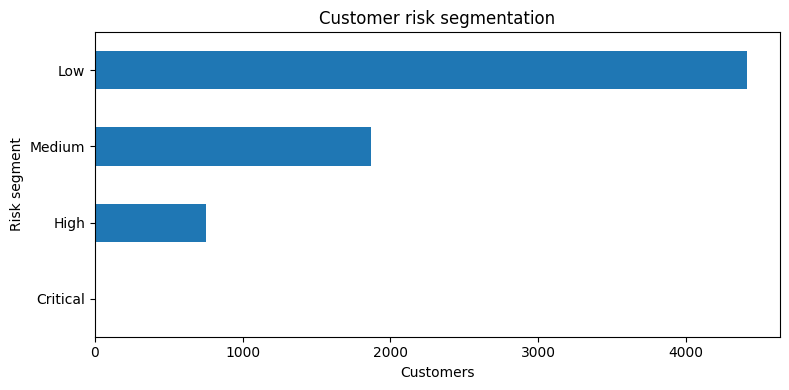

23081

In [0]:
scored_all_pd["risk_segment"] = pd.cut(
    scored_all_pd["churn_probability"],
    bins=[-np.inf, 0.30, 0.60, 0.80, np.inf],
    labels=["Low", "Medium", "High", "Critical"],
    right=False,
)

display(scored_all_pd.sort_values("churn_probability", ascending=False).head(25))

risk_summary = (
    scored_all_pd.groupby("risk_segment", observed=True)
    .agg(customers=("customerID", "count"), avg_probability=("churn_probability", "mean"))
    .reset_index()
    .sort_values("avg_probability", ascending=False)
    .round(4)
)
display(risk_summary)

# Native Matplotlib visualization from the exact table above.
risk_plot_pd = risk_summary.copy()
risk_plot_pd["risk_segment"] = risk_plot_pd["risk_segment"].astype(str)
ax = (
    risk_plot_pd
    .sort_values("customers")
    .plot.barh(
        x="risk_segment",
        y="customers",
        figsize=(8, 4),
        legend=False,
    )
)
ax.set_title("Customer risk segmentation")
ax.set_xlabel("Customers")
ax.set_ylabel("Risk segment")
plt.tight_layout()
plt.show()

# Save LR metrics before freeing the remote model.
lr_metrics_saved = dict(lr_metrics)

del lr_model
del pred_lr
gc.collect()


## 12. Model 2 — Random Forest
The Logistic Regression model has already been released from the Spark Connect ML cache before Random Forest is fitted.

Model,AUC_ROC,PR_AUC,Accuracy,Weighted_F1,Churn_Precision,Churn_Recall,Churn_F1,TN,FP,FN,TP
Random Forest,0.8279,0.6367,0.7814,0.7546,0.6943,0.3499,0.4653,967,59,249,134


feature,importance
tenure,0.19865795114363924
TotalCharges,0.13329773923906948
InternetService__Fiber_optic,0.1285491460350518
Contract__Two_year,0.09092229833794527
PaymentMethod__Electronic_check,0.080873262025899
InternetService__No,0.07533206950131528
MonthlyCharges,0.06494852530715578
TechSupport__Yes,0.04750675705656627
Contract__One_year,0.03925209629059703
charges_per_month,0.028620024852034683


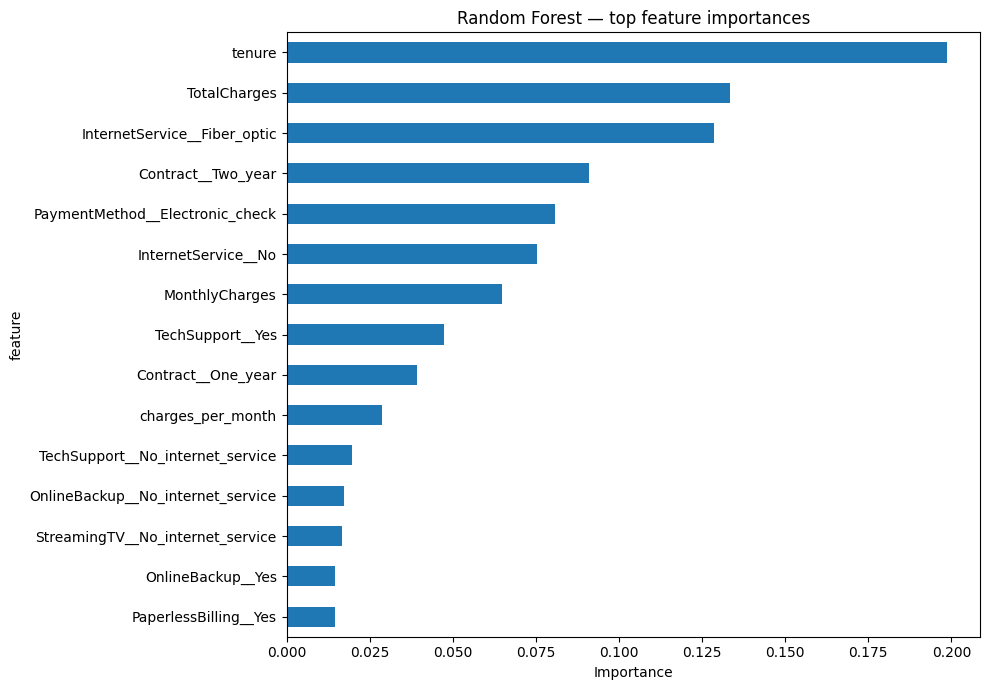

Feature importance describes model usage, not causal impact.


10558

In [0]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=20,
    maxDepth=4,
    maxBins=32,
    seed=42,
)

rf_model = rf.fit(train_vec)
pred_rf = rf_model.transform(test_vec)
rf_metrics = evaluate_predictions(pred_rf, "Random Forest")
display(pd.DataFrame([rf_metrics]).round(4))

# Feature importances map directly to deterministic feature_cols.
rf_importance_pd = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.featureImportances.toArray(),
}).sort_values("importance", ascending=False)

display(rf_importance_pd.head(20))

ax = (
    rf_importance_pd.head(15)
    .sort_values("importance")
    .plot.barh(x="feature", y="importance", figsize=(10, 7), legend=False)
)
ax.set_title("Random Forest — top feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
print("Feature importance describes model usage, not causal impact.")

rf_metrics_saved = dict(rf_metrics)

del rf_model
del pred_rf
gc.collect()

## 13. Model comparison

The executed metrics table is followed by native Matplotlib visualizations: a grouped metric comparison and one confusion matrix per model.

AUC_ROC,PR_AUC,Accuracy,Weighted_F1,Churn_Precision,Churn_Recall,Churn_F1,TN,FP,FN,TP
0.8369,0.6347,0.7921,0.78,0.6642,0.4752,0.554,934,92,201,182
0.8279,0.6367,0.7814,0.7546,0.6943,0.3499,0.4653,967,59,249,134


Champion by ROC-AUC: Logistic Regression


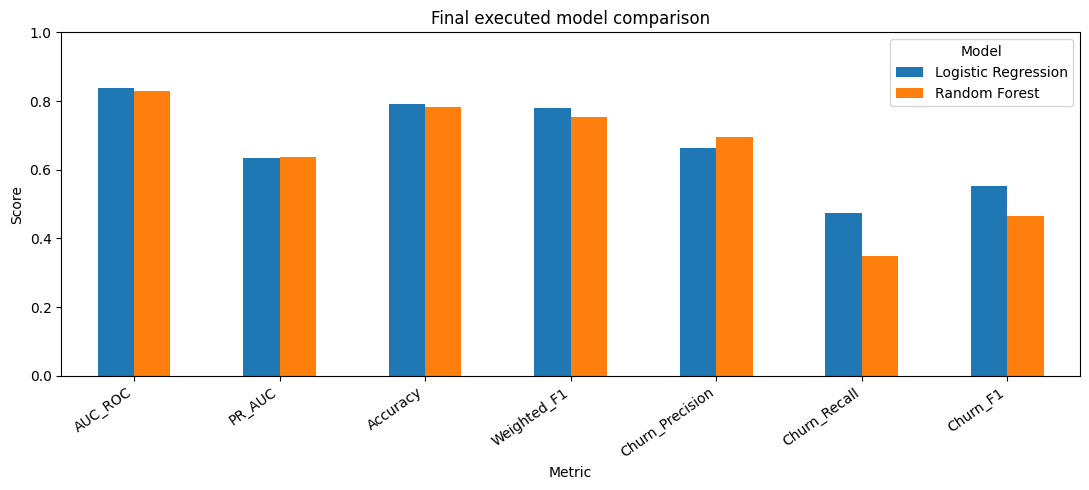

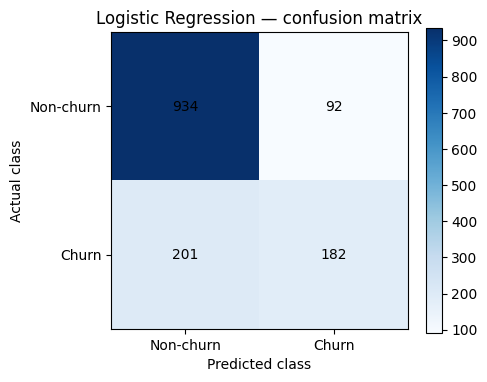

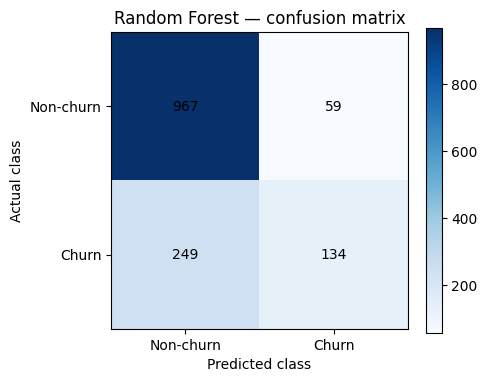

In [0]:
results_df = pd.DataFrame([lr_metrics_saved, rf_metrics_saved]).set_index("Model")
display(results_df.round(4))
print(f"Champion by ROC-AUC: {results_df['AUC_ROC'].idxmax()}")

# Native Matplotlib comparison using the exact executed metrics above.
comparison_metrics = [
    "AUC_ROC",
    "PR_AUC",
    "Accuracy",
    "Weighted_F1",
    "Churn_Precision",
    "Churn_Recall",
    "Churn_F1",
]
comparison_plot = results_df[comparison_metrics].T

ax = comparison_plot.plot.bar(figsize=(11, 5))
ax.set_title("Final executed model comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Confusion matrices generated directly from the executed model metrics.
for model_name, metrics in [
    ("Logistic Regression", lr_metrics_saved),
    ("Random Forest", rf_metrics_saved),
]:
    cm = np.array([
        [metrics["TN"], metrics["FP"]],
        [metrics["FN"], metrics["TP"]],
    ])

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{model_name} — confusion matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_xticks([0, 1], labels=["Non-churn", "Churn"])
    ax.set_yticks([0, 1], labels=["Non-churn", "Churn"])

    for row in range(2):
        for col in range(2):
            ax.text(
                col,
                row,
                f"{int(cm[row, col])}",
                ha="center",
                va="center",
            )

    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()


## 14. Business recommendations

1. **Month-to-month customers (42.71% churn)** — test longer-contract incentives among high-risk customers.
2. **Low-tenure customers (median churner tenure 10 months)** — strengthen first-year onboarding and proactive support.
3. **No TechSupport (41.64%) / No OnlineSecurity (41.77%)** — test targeted service bundles.
4. **Electronic check (45.29%)** — investigate billing friction / engagement mechanisms before intervening.
5. **Senior customers (41.68%)** — test more personalized support with an appropriate fairness review.

These recommendations are hypotheses based on observed associations. Business impact should be validated experimentally.

## 15. Production roadmap
A production version would add:
- MLflow experiment tracking
- Model Registry
- scheduled batch scoring
- Delta prediction tables
- validation-based, cost-aware threshold calibration
- probability calibration checks
- data / prediction drift monitoring
- fairness monitoring
- retraining strategy
- CRM integration

## 16. Final conclusion
This project demonstrates a complete churn workflow in Databricks using PySpark for data processing and Spark ML for classification, while remaining compatible with the memory constraints of Free Edition serverless compute.

The final model choice must be based on the metrics produced by the current execution. For a retention use case, churn recall, churn F1, false negatives and business cost should be considered alongside ROC-AUC.